# Spiral arms from a satellite flyby

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/sgpfaff/tambora-docs/blob/master/docs/examples/10-spiral-arms.ipynb)

Grand-design spirals — two clean, symmetric arms — are not something a disk
does spontaneously. Left alone, a disk that is cool enough to make arms tends
to make a bar instead ([example 09](09-disk-instability.ipynb)), and a disk hot
enough to avoid the bar makes only flocculent, transient scraps. The tidiest
way to get two long arms is to have something fly past.

M51 is the standard example: a grand-design spiral with NGC 5195 sitting right
at the end of one arm. Toomre & Toomre (1972) showed that a companion on a
close passage will do this, and — crucially — that it matters enormously which
way round the companion goes.

This notebook is built around that second point, because it is the part that is
easy to state and easy to get wrong:

> A **prograde** encounter, where the companion orbits in the same sense as the
> disk rotates, drives strong two-armed spirals. A **retrograde** encounter,
> with everything else identical, barely does anything.

The reason is resonance. In a prograde passage the companion's angular speed
stays close to the disk material's for a long time, so the perturbation pushes
the same stars in the same direction over and over. Retrograde, the companion
sweeps past the disk material and the forcing averages away.

**Runtime.** About 4 minutes for three runs at the default resolution, well
under a minute with `QUICK = True`.

## Setup

In [1]:
# Colab / fresh environment only:
%pip install --pre --quiet "tambora==0.1.0a1" galpy astropy matplotlib

Note: you may need to restart the kernel to use updated packages.


In [2]:
import warnings

import astropy.units as u
import matplotlib.pyplot as plt
import numpy as np
from galpy import potential
from galpy.orbit import Orbit
from galpy.potential import DoubleExponentialDiskPotential, NFWPotential

import tambora
from tambora.simulation import Sim
from tambora.tools import mkPlummer_galpy
from tambora.tools.util.units import G_KPC_KMS

print("tambora", tambora.__version__)

try:
    plt.style.use("../_static/tambora.mplstyle")
except OSError:
    pass

np.random.seed(31)

QUICK = False  # True -> 6000 particles, coarser output

tambora 0.1.0a1


## 1. A disk that is stable on its own

This is the part to get right before anything else. If the disk goes
bar-unstable by itself, every arm we see afterwards could be its own doing
rather than the satellite's — and we would have no way to tell.

So we borrow the stable configuration from
[example 09](09-disk-instability.ipynb): a disk carrying a minority of the
rotation curve, inside a dominant halo, which that notebook showed sits at the
noise floor for 2 Gyr. Then we *check* it, with a control run.

In [3]:
M_DISK = 2.5e10  # disk mass [Msun]
H_R = 3.5  # radial scale length [kpc]
H_Z = 0.30  # vertical scale height [kpc]
R_MAX = 5.0 * H_R
M_HALO = 4.0e11  # NFW halo mass [Msun]
A_HALO = 14.0  # NFW scale radius [kpc]
Q0 = 1.5  # Toomre Q: warm enough to be safe, cool enough to amplify


def _pot(m_disk, m_halo):
    rho0 = m_disk / (4.0 * np.pi * H_R**2 * H_Z)
    d = DoubleExponentialDiskPotential(
        amp=rho0 * u.Msun / u.kpc**3, hr=H_R * u.kpc, hz=H_Z * u.kpc, ro=8.0, vo=220.0
    )
    h = NFWPotential(amp=m_halo * u.Msun, a=A_HALO * u.kpc, ro=8.0, vo=220.0)
    for q in (d, h):
        q.turn_physical_on()
    return d, h


disk_pot, halo_pot = _pot(M_DISK, M_HALO)
model = [disk_pot, halo_pot]


def vc_of(pot, R):
    """Circular speed [km/s] at radii R [kpc], quietly.

    DoubleExponentialDiskPotential integrates by tanh-sinh quadrature and
    overflows harmlessly in the tails; passing ro/vo explicitly makes vcirc
    return km/s as a plain float for a potential list.
    """
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", RuntimeWarning)
        return np.array(
            [float(potential.vcirc(pot, float(r) * u.kpc, ro=8.0, vo=220.0))
             for r in np.atleast_1d(R)]
        )


# Expensive potential -> evaluate on a grid once and interpolate.
R_grid = np.linspace(0.05, R_MAX * 1.3, 150)
vc_grid = vc_of(model, R_grid)
Om_grid = vc_grid / R_grid
ka_grid = np.sqrt(
    np.clip(R_grid * np.gradient(Om_grid**2, R_grid) + 4.0 * Om_grid**2, 1e-12, None)
)

print(f"v_c(2 h_R) = {vc_of(model, 2 * H_R)[0]:.0f} km/s")
print(f"disk share of v_c^2 at 2 h_R = "
      f"{vc_of(disk_pot, 2 * H_R)[0]**2 / vc_of(model, 2 * H_R)[0]**2:.2f}")

/private/tmp/claude-501/-Users-gabrielpfaffman-Repos-tambora-docs/67f2c9a1-fd52-4fb9-a988-3ccca0e9a3dc/scratchpad/tamboraenv/lib/python3.13/site-packages/galpy/potential/DoubleExponentialDiskPotential.py:19: RuntimeWarning: overflow encountered in sinh
  return (numpy.sinh(numpy.pi * numpy.sinh(t)) + numpy.pi * t * numpy.cosh(t)) / (

/private/tmp/claude-501/-Users-gabrielpfaffman-Repos-tambora-docs/67f2c9a1-fd52-4fb9-a988-3ccca0e9a3dc/scratchpad/tamboraenv/lib/python3.13/site-packages/galpy/potential/DoubleExponentialDiskPotential.py:20: RuntimeWarning: overflow encountered in cosh
  numpy.cosh(numpy.pi * numpy.sinh(t)) + 1

/private/tmp/claude-501/-Users-gabrielpfaffman-Repos-tambora-docs/67f2c9a1-fd52-4fb9-a988-3ccca0e9a3dc/scratchpad/tamboraenv/lib/python3.13/site-packages/galpy/potential/DoubleExponentialDiskPotential.py:19: RuntimeWarning: invalid value encountered in divide
  return (numpy.sinh(numpy.pi * numpy.sinh(t)) + numpy.pi * t * numpy.cosh(t)) / (

v_c(2 h_R) = 170 km/s


### The disk sampler, with a spin switch

Same double-exponential construction as
[example 08](08-ring-galaxy.ipynb) — sample $\rho \propto e^{-R/h_R}e^{-|z|/h_z}$,
then set velocities from $v_c$, the Toomre $Q$ and asymmetric drift.

The one addition is `spin`. This is how we get a clean prograde/retrograde
comparison: rather than building two different satellite orbits and hoping they
are equivalent, we keep **one** orbit and flip the direction the disk turns.
The satellite's *initial conditions* are then identical to the last decimal
place, and the sense of rotation is the only thing we varied.

Its *trajectory* does not stay identical, and that is worth watching rather
than glossing over. The disk pulls back on the satellite, and how hard depends
on how well the two are coupled — which is precisely what prograde versus
retrograde changes. We measure the divergence below; it is dynamical friction
doing its job, not a broken setup.

In [4]:
def make_disk(n, spin=+1, Q=Q0, seed=0):
    """Double-exponential disk in centrifugal + epicyclic equilibrium.

    ``spin=+1`` rotates counter-clockwise seen from +z, ``spin=-1`` clockwise.
    """
    r = np.random.default_rng(seed)

    RR = np.linspace(0.0, R_MAX, 4000)
    cdf = 1.0 - (1.0 + RR / H_R) * np.exp(-RR / H_R)
    cdf /= cdf[-1]
    R = np.interp(r.random(n), cdf, RR)

    phi = r.uniform(0.0, 2.0 * np.pi, n)
    z = np.where(r.random(n) < 0.5, -1.0, 1.0) * (-H_Z * np.log(r.random(n)))
    pos = np.column_stack([R * np.cos(phi), R * np.sin(phi), z])

    vc = np.interp(R, R_grid, vc_grid)
    Om = np.interp(R, R_grid, Om_grid)
    ka = np.interp(R, R_grid, ka_grid)

    Sigma = M_DISK / (2.0 * np.pi * H_R**2) * np.exp(-R / H_R)
    sigma_R = Q * 3.36 * G_KPC_KMS * Sigma / ka
    sigma_phi = sigma_R * ka / (2.0 * Om)
    sigma_z = np.sqrt(2.0 * np.pi * G_KPC_KMS * Sigma * H_Z)

    drift = sigma_R**2 * (1.0 - ka**2 / (4.0 * Om**2) - 2.0 * R / H_R)
    v_phi = np.sqrt(np.clip(vc**2 + drift, 0.0, None)) + r.normal(0.0, sigma_phi)
    v_R = r.normal(0.0, sigma_R)

    # `spin` reverses the streaming motion only; the random motions are
    # isotropic in the plane and are left exactly as drawn.
    vel = np.column_stack(
        [
            v_R * np.cos(phi) - spin * v_phi * np.sin(phi),
            v_R * np.sin(phi) + spin * v_phi * np.cos(phi),
            r.normal(0.0, sigma_z),
        ]
    )

    # Sampling leaves a net momentum of order sigma/sqrt(N); left in, it walks
    # the disk off the plane over a Gyr and mimics real evolution.
    pos -= pos.mean(axis=0)
    vel -= vel.mean(axis=0)
    return pos, vel, np.full(n, M_DISK / n)

## 2. The satellite and its orbit

Design the trajectory with galpy first, so we know what we are getting before
spending any N-body time on it. We want a pericentre of roughly two disk scale
lengths — close enough to matter, far enough that the satellite does not simply
plough through the middle and make a ring
([example 08](08-ring-galaxy.ipynb) covers that case).

In [5]:
M_SAT = 0.4 * M_DISK  # satellite mass [Msun]
B_SAT = 1.5  # Plummer scale radius [kpc]

o = Orbit(
    [
        38.0 * u.kpc,  # R
        -140.0 * u.km / u.s,  # vR: falling inward
        95.0 * u.km / u.s,  # vT
        0.0 * u.kpc,  # z: in the disk plane
        0.0 * u.km / u.s,  # vz
        0.0 * u.deg,  # phi
    ]
)
o.turn_physical_on()
with warnings.catch_warnings():
    warnings.simplefilter("ignore", RuntimeWarning)
    o.integrate(np.linspace(0, 1.5, 1500) * u.Gyr, model)

print(f"pericentre   {o.rperi():.1f} kpc   ({o.rperi() / H_R:.1f} h_R)")
print(f"apocentre    {o.rap():.1f} kpc")
print(f"satellite mass {M_SAT:.2e} Msun = {M_SAT / M_DISK:.1f} M_disk")

sat_pos = np.array([o.x(), o.y(), o.z()])
sat_vel = np.array([o.vx(), o.vy(), o.vz()])
print(f"start at {sat_pos.round(1)} kpc, v = {sat_vel.round(1)} km/s")

pericentre   11.1 kpc   (3.2 h_R)
apocentre    59.4 kpc
satellite mass 1.00e+10 Msun = 0.4 M_disk
start at [38.  0.  0.] kpc, v = [-140.   95.    0.] km/s


The satellite orbits counter-clockwise (its $v_T > 0$). So `spin=+1` is the
**prograde** case and `spin=-1` is **retrograde**.

## 3. Three runs

Control, prograde, retrograde. The control has no satellite at all and exists
to prove the disk is not doing this by itself.

In [6]:
N = 6000 if QUICK else 20000
T_END = 0.6 if QUICK else 1.0
DT = 5e-4
DT_OUT = 1e-2 if QUICK else 5e-3
EPS = {"disk": 0.10, "sat": 0.40}


def run_case(name, spin, with_sat):
    pos, vel, mass = make_disk(N, spin=spin, seed=31)
    s = Sim()
    s.add_particles("disk", pos, vel, mass)
    if with_sat:
        sp, sv, sm = mkPlummer_galpy(
            m=M_SAT, b=B_SAT, n=max(N // 8, 800),
            center_pos=sat_pos, center_vel=sat_vel,
        )
        s.add_particles("sat", sp, sv, sm)
    s.add_external_pot(halo_pot)

    print(f"\n=== {name} ===")
    s.run(t_end=T_END, dt=DT, dt_out=DT_OUT,
          eps=(EPS if with_sat else EPS["disk"]), theta=0.6)
    print(f"|dE/E0| = {s.monitor.drift['energy'][-1]:.2e}")
    return s


sim_ctrl = run_case("control (no satellite)", +1, False)
sim_pro = run_case("prograde", +1, True)
sim_ret = run_case("retrograde", -1, True)


=== control (no satellite) ===


  0%|          | 0/2000 [00:00<?, ?it/s]

  0%|          | 8/2000 [00:00<00:26, 75.82it/s, |dE/E0|=0.00e+00]

  1%|          | 17/2000 [00:00<00:23, 83.00it/s, |dE/E0|=5.51e-08]

  1%|▏         | 26/2000 [00:00<00:23, 85.76it/s, |dE/E0|=8.32e-07]

...

 99%|█████████▉| 1986/2000 [00:28<00:00, 68.54it/s, |dE/E0|=2.64e-05]

100%|█████████▉| 1993/2000 [00:28<00:00, 68.39it/s, |dE/E0|=2.70e-05]

100%|██████████| 2000/2000 [00:28<00:00, 68.24it/s, |dE/E0|=2.90e-05]

100%|██████████| 2000/2000 [00:28<00:00, 70.70it/s, |dE/E0|=2.90e-05]

|dE/E0| = 2.90e-05


## 4. Measuring arm strength

The same $m = 2$ Fourier amplitude used for the bar in
[example 09](09-disk-instability.ipynb), but measured in an **annulus** rather
than the centre. Arms live at intermediate radii; a bar lives in the middle,
and measuring over the whole disk would mix the two.

In [7]:
R_IN, R_OUT = 4.0, 14.0


def arm_amplitude(s, t_idx):
    x, y, m = s.disk.x(t=t_idx), s.disk.y(t=t_idx), s.disk.mass
    R = np.hypot(x, y)
    sel = (R > R_IN) & (R < R_OUT)
    if sel.sum() == 0:
        return 0.0
    c = np.sum(m[sel] * np.exp(2j * np.arctan2(y[sel], x[sel])))
    return np.abs(c) / m[sel].sum()


A2 = {}
for label, s in [("control", sim_ctrl), ("prograde", sim_pro), ("retrograde", sim_ret)]:
    A2[label] = np.array([arm_amplitude(s, i) for i in range(len(s.times))])

noise = 1.0 / np.sqrt(N)
for label in A2:
    print(f"{label:11s} A_2: peak {A2[label].max():.3f}  end {A2[label][-1]:.3f}")
print(f"shot-noise floor ~ {noise:.3f}")

control     A_2: peak 0.027  end 0.003
prograde    A_2: peak 0.222  end 0.047
retrograde  A_2: peak 0.052  end 0.006
shot-noise floor ~ 0.007


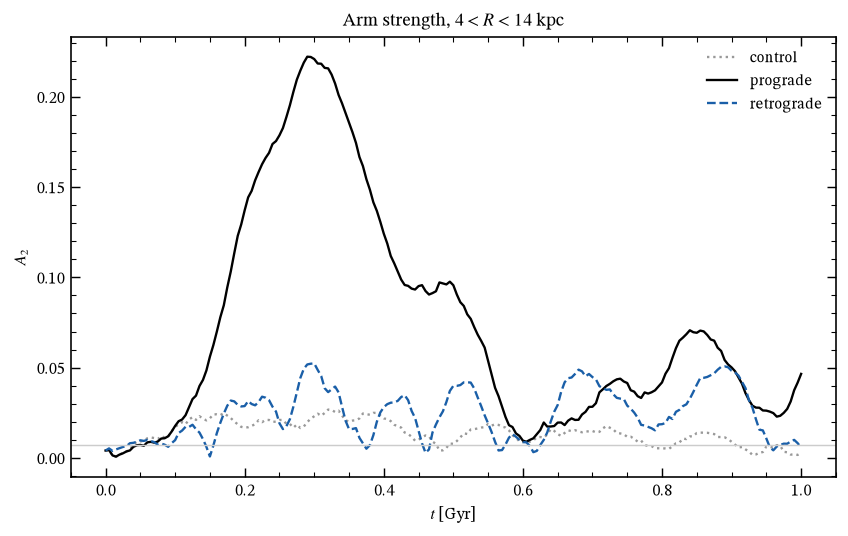

In [8]:
fig, ax = plt.subplots(figsize=(6.6, 4.2))
for label, c, ls in [("control", "0.6", ":"), ("prograde", "k", "-"),
                     ("retrograde", "#1a5fa8", "--")]:
    ax.plot(sim_ctrl.times[: len(A2[label])], A2[label], c=c, ls=ls, label=label)
ax.axhline(noise, c="0.8", lw=0.8)
ax.set_xlabel("$t$ [Gyr]")
ax.set_ylabel("$A_2$")
ax.set_title(f"Arm strength, ${R_IN:.0f} < R < {R_OUT:.0f}$ kpc")
ax.legend()
fig.tight_layout()
plt.show()

### The satellite does not follow the same path in both runs

Identical initial conditions, identical perturber, identical everything except
the direction the disk spins — and the orbits still separate. A prograde
satellite couples resonantly to the disk it is stirring up, so it transfers
more orbital energy and sinks faster. Retrograde, the coupling is weak and the
orbit is closer to the test-particle one galpy predicted.

This is a good reminder that "I only changed one variable" is a statement about
the *setup*, not about everything downstream of it.

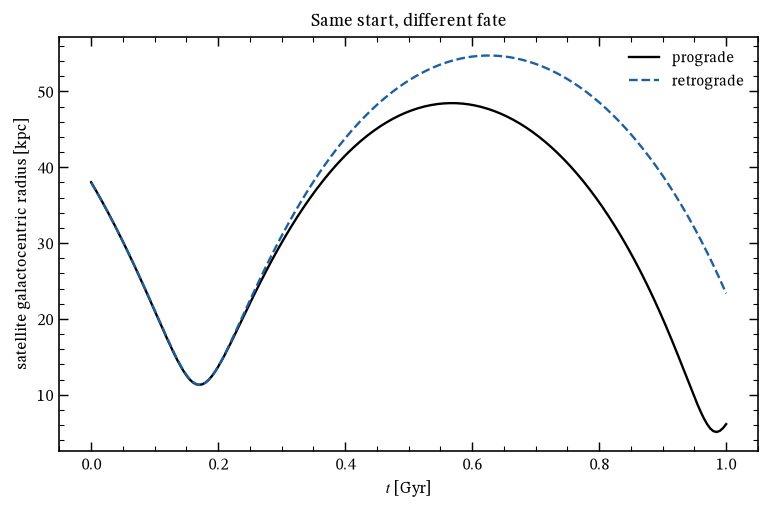

at t = 1.00 Gyr:
  prograde   r =    6.1 kpc
  retrograde r =   23.4 kpc
  difference   =   17.2 kpc


In [9]:
def sat_radius(s):
    return np.array(
        [np.linalg.norm([s.sat.x(t=i).mean(), s.sat.y(t=i).mean(), s.sat.z(t=i).mean()])
         for i in range(len(s.times))]
    )


r_pro, r_ret = sat_radius(sim_pro), sat_radius(sim_ret)

fig, ax = plt.subplots(figsize=(6.0, 4.0))
ax.plot(sim_pro.times, r_pro, "k", label="prograde")
ax.plot(sim_ret.times, r_ret, c="#1a5fa8", ls="--", label="retrograde")
ax.set_xlabel("$t$ [Gyr]")
ax.set_ylabel("satellite galactocentric radius [kpc]")
ax.set_title("Same start, different fate")
ax.legend()
fig.tight_layout()
plt.show()

print(f"at t = {sim_pro.times[-1]:.2f} Gyr:")
print(f"  prograde   r = {r_pro[-1]:6.1f} kpc")
print(f"  retrograde r = {r_ret[-1]:6.1f} kpc")
print(f"  difference   = {abs(r_pro[-1] - r_ret[-1]):6.1f} kpc")

## 5. What it looks like

The control is the row to check first. If it stays smooth, the arms in the
prograde row are the satellite's doing.

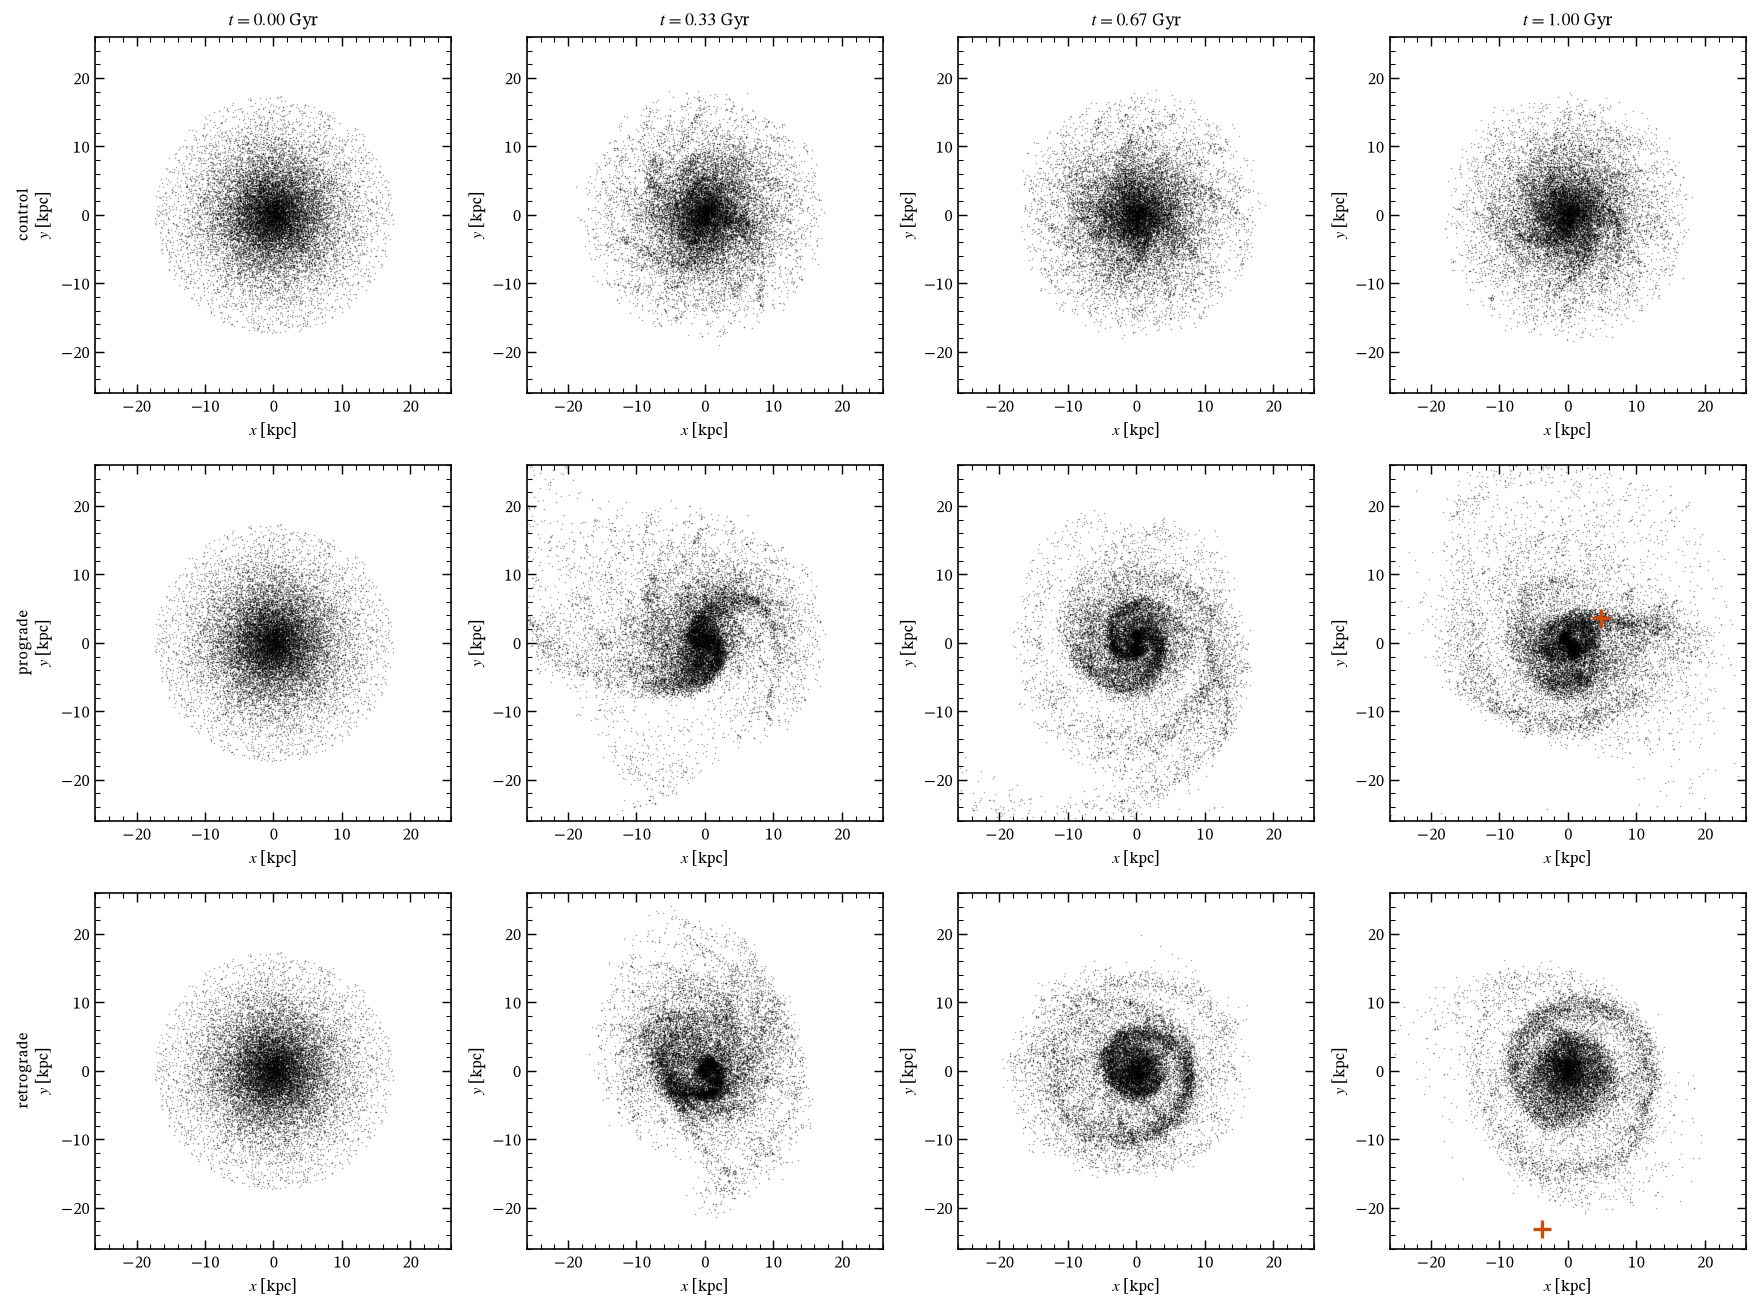

In [10]:
t_show = np.linspace(0.0, sim_ctrl.times[-1], 4)
fig, axes = plt.subplots(3, 4, figsize=(13.6, 10.2))

for row, (s, label) in enumerate(
    [(sim_ctrl, "control"), (sim_pro, "prograde"), (sim_ret, "retrograde")]
):
    for col, t in enumerate(t_show):
        ax = axes[row, col]
        ax.scatter(s.disk.x(t=float(t)), s.disk.y(t=float(t)),
                   s=0.7, lw=0, c="k", alpha=0.35)
        if "sat" in [c.name for c in s.components]:
            ax.plot(s.sat.x(t=float(t)).mean(), s.sat.y(t=float(t)).mean(),
                    "+", c="#d94801", ms=10, mew=1.8)
        ax.set_xlim(-26, 26)
        ax.set_ylim(-26, 26)
        ax.set_aspect("equal")
        ax.set_xlabel("$x$ [kpc]")
        ax.set_ylabel(f"{label}\n$y$ [kpc]" if col == 0 else "$y$ [kpc]")
        if row == 0:
            ax.set_title(f"$t = {t:.2f}$ Gyr")

fig.tight_layout()
plt.show()

## 6. The animation

Prograde and retrograde side by side, with $A_2$ tracking underneath. The
satellite is the orange marker. It starts from the same place in both panels
and then drifts apart, because the prograde disk grips it harder.

60 frames, 3.1 MB


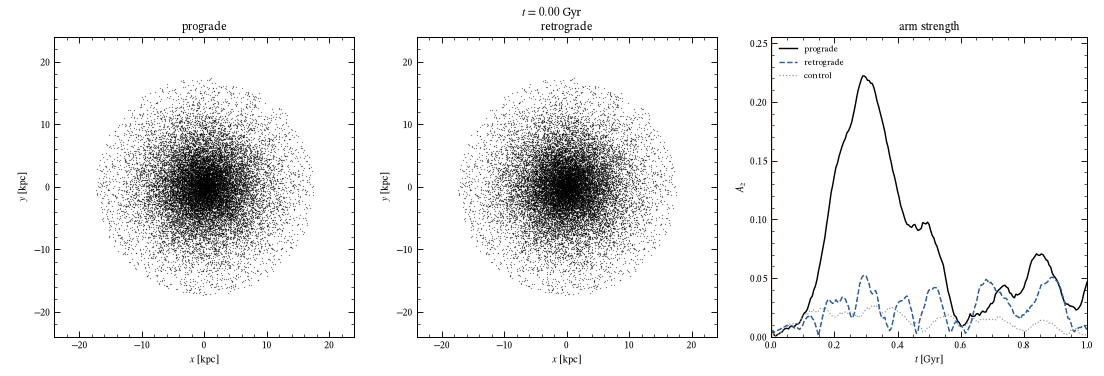

In [11]:
from IPython.display import Image  # noqa: E402
from matplotlib.animation import FuncAnimation, PillowWriter  # noqa: E402

t_anim = np.linspace(0.0, sim_pro.times[-1], 60)
idx_anim = np.searchsorted(sim_pro.times, t_anim).clip(0, len(sim_pro.times) - 1)

LIM = 24.0
fig, (ax_p, ax_r, ax_a) = plt.subplots(1, 3, figsize=(13.8, 4.7))

sc_p = ax_p.scatter([], [], s=1.4, lw=0, c="k", alpha=0.5)
(mk_p,) = ax_p.plot([], [], "+", c="#d94801", ms=11, mew=2.0)
ax_p.set_title("prograde")

sc_r = ax_r.scatter([], [], s=1.4, lw=0, c="k", alpha=0.5)
(mk_r,) = ax_r.plot([], [], "+", c="#d94801", ms=11, mew=2.0)
ax_r.set_title("retrograde")

for ax in (ax_p, ax_r):
    ax.set_xlim(-LIM, LIM)
    ax.set_ylim(-LIM, LIM)
    ax.set_aspect("equal")
    ax.set_xlabel("$x$ [kpc]")
    ax.set_ylabel("$y$ [kpc]")

ax_a.plot(sim_pro.times, A2["prograde"], "k", lw=1.3, label="prograde")
ax_a.plot(sim_ret.times, A2["retrograde"], c="#1a5fa8", ls="--", lw=1.3,
          label="retrograde")
ax_a.plot(sim_ctrl.times, A2["control"], c="0.6", ls=":", lw=1.1, label="control")
(vline,) = ax_a.plot([], [], c="#d94801", lw=1.3)
ax_a.set_xlim(0, sim_pro.times[-1])
ax_a.set_ylim(0, max(A2["prograde"].max(), A2["retrograde"].max()) * 1.15)
ax_a.set_xlabel("$t$ [Gyr]")
ax_a.set_ylabel("$A_2$")
ax_a.set_title("arm strength")
ax_a.legend(fontsize=8, loc="upper left")

ttl = fig.suptitle("")
fig.tight_layout()


def update(k):
    i = int(idx_anim[k])
    sc_p.set_offsets(np.c_[sim_pro.disk.x(t=i), sim_pro.disk.y(t=i)])
    sc_r.set_offsets(np.c_[sim_ret.disk.x(t=i), sim_ret.disk.y(t=i)])
    mk_p.set_data([sim_pro.sat.x(t=i).mean()], [sim_pro.sat.y(t=i).mean()])
    mk_r.set_data([sim_ret.sat.x(t=i).mean()], [sim_ret.sat.y(t=i).mean()])
    t = sim_pro.times[i]
    vline.set_data([t, t], [0, ax_a.get_ylim()[1]])
    ttl.set_text(f"$t = {t:.2f}$ Gyr")
    return sc_p, sc_r, mk_p, mk_r, vline, ttl


anim = FuncAnimation(fig, update, frames=range(len(idx_anim)), blit=False)
anim.save("spiral_arms.gif", writer=PillowWriter(fps=6), dpi=80)
plt.close(fig)

from PIL import Image as PILImage, ImageSequence  # noqa: E402

_src = PILImage.open("spiral_arms.gif")
_fr = [f.copy().convert("RGB").quantize(colors=64, method=PILImage.MEDIANCUT)
       for f in ImageSequence.Iterator(_src)]
_fr[0].save("spiral_arms.gif", save_all=True, append_images=_fr[1:],
            duration=180, loop=0, optimize=True)
print(f"{len(_fr)} frames, "
      f"{__import__('os').path.getsize('spiral_arms.gif') / 1e6:.1f} MB")

Image(filename="spiral_arms.gif")

## 7. Caveats worth carrying forward

- **The halo is rigid.** No dynamical friction, so the satellite does not decay
  and eventually merge. Over one passage that is fine; do not use this setup to
  ask what happens next.
- **These arms are kinematic density waves in a collisionless disk.** Real
  grand-design arms are where gas piles up, shocks, and forms stars, which is
  what makes them bright. There is no gas here, so do not compare arm contrasts
  with observed ones.
- **Warm disk, modest self-gravity.** $Q = 1.5$ in a halo-dominated disk keeps
  the disk from barring, but it also limits how strongly swing amplification can
  amplify the response. A cooler, more self-gravitating disk gives stronger arms
  and eventually a bar — worth scanning if you care about the amplitude.

## Summary

- Check that your disk is stable *before* attributing structure to a perturber.
  The control run is not optional.
- Flip the disk's spin, not the satellite's orbit, to compare prograde against
  retrograde: the perturbation is then bit-for-bit identical.
- $m = 2$ measured in an annulus is the arm diagnostic; measured in the centre
  it is the bar diagnostic.